# ML: SUPERVISED LEARNING: CUSTOMER_CHURN PREDICTOR

## PHASE 0 - ENVIROMENT SETUP: Installing and importing libraries

In [2]:
# Install all the packages and the neccessaries libraries

import sys
import subprocess

Packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "xgboost",
    "imbalanced-learn",
    "openpyxl"
]

for Package in Packages:
    subprocess.check_call([sys.executable, '-m','pip','install',Package,'--quiet'])

print("All packages are installed successfully")

# Import all core data libraries

import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Manchine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",100)
pd.set_option("display.float_format","{:.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10,6)
%matplotlib inline

print("All libraries are imported successfully")

All packages are installed successfully
All libraries are imported successfully


## Phase 1: Loading & Reading the Dataset

In [3]:
df = pd.read_excel(r"C:\Users\USER\Downloads\Customer Churn Dataset.xlsx")

print(f"Dataset Loaded successfully, Dataset shape:{df.shape}")

Dataset Loaded successfully, Dataset shape:(7043, 21)


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Checking the null values, data types, dataset information

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

In [7]:
# __Checking the data types of the dataset

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [8]:
# Dataset Structure

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:

# Filling the missing values in the Totalcharge with zero to complement the dataset column
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
# Checking the uniques values the dataset columns

cat_cols = df.select_dtypes(include=["str"]).columns.tolist()

for cat in cat_cols:
    print(f"{cat:20s} > {df[cat].unique().tolist()}")

customerID           > ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU', '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU', '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS', '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB', '8779-QRDMV', '1680-VDCWW', '1066-JKSGK', '3638-WEABW', '6322-HRPFA', '6865-JZNKO', '6467-CHFZW', '8665-UTDHZ', '5248-YGIJN', '8773-HHUOZ', '3841-NFECX', '4929-XIHVW', '6827-IEAUQ', '7310-EGVHZ', '3413-BMNZE', '6234-RAAPL', '6047-YHPVI', '6572-ADKRS', '5380-WJKOV', '8168-UQWWF', '8865-TNMNX', '9489-DEDVP', '9867-JCZSP', '4671-VJLCL', '4080-IIARD', '3714-NTNFO', '5948-UJZLF', '7760-OYPDY', '7639-LIAYI', '2954-PIBKO', '8012-SOUDQ', '9420-LOJKX', '6575-SUVOI', '7495-OOKFY', '4667-QONEA', '1658-BYGOY', '8769-KKTPH', '5067-XJQFU', '3957-SQXML', '5954-BDFSG', '0434-CSFON', '1215-FIGMP', '0526-SXDJP', '0557-ASKVU', '5698-BQJOH', '5122-CYFXA', '8627-ZYGSZ', '3410-YOQBQ', '3170-NMYVV', '7410-OIED

In [11]:
# Baseline Target
# roc_auc_score > 0.84
# precision_score > 72% for  both churn and No churn

In [12]:

df["MultipleLines"].value_counts()
df["OnlineSecurity"].value_counts()
df["OnlineBackup"].value_counts()
df["DeviceProtection"].value_counts()
df["TechSupport"].value_counts()
df["StreamingTV"].value_counts()
df["StreamingMovies"].value_counts()


#df.head(10)

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [13]:
num_cols = df.select_dtypes(include=["int","float"]).columns.tolist()
print("="*50)
print (f"columns numbers includes:")

for num in num_cols:
    print(f"{num:20s} > {df[num].unique().tolist()}")


columns numbers includes:
SeniorCitizen        > [0, 1]
tenure               > [1, 34, 2, 45, 8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71, 21, 12, 30, 47, 72, 17, 27, 5, 46, 11, 70, 63, 43, 15, 60, 18, 66, 9, 3, 31, 50, 64, 56, 7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37, 36, 41, 6, 4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19, 54, 51, 26, 0, 39]
MonthlyCharges       > [29.85, 56.95, 53.85, 42.3, 70.7, 99.65, 89.1, 29.75, 104.8, 56.15, 49.95, 18.95, 100.35, 103.7, 105.5, 113.25, 20.65, 106.7, 55.2, 90.05, 39.65, 19.8, 20.15, 59.9, 59.6, 55.3, 99.35, 30.2, 90.25, 64.7, 96.35, 95.5, 66.15, 20.2, 45.25, 99.9, 69.7, 74.8, 106.35, 97.85, 49.55, 69.2, 20.75, 79.85, 76.2, 84.5, 49.25, 80.65, 79.75, 64.15, 99.1, 69.5, 74.85, 95.45, 108.45, 24.95, 107.5, 100.5, 89.9, 42.1, 54.4, 94.4, 75.3, 78.9, 79.2, 49.05, 20.4, 111.6, 24.25, 64.5, 110.5, 55.65, 54.65, 74.75, 25.9, 79.35, 50.55, 75.15, 103.8, 99.3, 62.15, 19.95, 33.75, 82.05, 74.7, 84.0, 111.05, 100.9, 78.95, 66.85, 21.05, 21.0,

In [14]:
df.head(5)

df = df.drop(columns=["customerID"])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## PHASE 2: Encode all the categories columns ##

In [15]:
# Convert all the NO internet service as NO in these set of columns (MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies)

No_internet = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in No_internet:
    df[col] = df[col].replace({"No phone service":"No",
                               "No internet service":"No"})

    
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:

No_internet = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]
for col in No_internet:
    print(f"{col:20s} > {df[col].unique().tolist()}")

MultipleLines        > ['No', 'Yes']
OnlineSecurity       > ['No', 'Yes']
OnlineBackup         > ['Yes', 'No']
DeviceProtection     > ['No', 'Yes']
TechSupport          > ['No', 'Yes']
StreamingTV          > ['No', 'Yes']
StreamingMovies      > ['No', 'Yes']


In [17]:
df.head()

# Encode all the column to have uniform set
binary_column = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

binary_map = {"Male":1, "Female":0, "Yes":1, "No":0}
for col in binary_column:
    print(f"{col:20s} > {df[col].unique().tolist()}")
    df[col]= df[col].map(binary_map)


# Encode all the target variable for both (Churn and Non-churn customers)

df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

print("="*50)

print("Mapped successful")



gender               > ['Female', 'Male']
Partner              > ['Yes', 'No']
Dependents           > ['No', 'Yes']
PhoneService         > ['No', 'Yes']
MultipleLines        > ['No', 'Yes']
OnlineSecurity       > ['No', 'Yes']
OnlineBackup         > ['Yes', 'No']
DeviceProtection     > ['No', 'Yes']
TechSupport          > ['No', 'Yes']
StreamingTV          > ['No', 'Yes']
StreamingMovies      > ['No', 'Yes']
PaperlessBilling     > ['Yes', 'No']
Mapped successful


In [18]:
# Using OneHotEncoder to encode the columns for multi-categories values

mult_cat = [
    "InternetService",
    "Contract",
    "PaymentMethod"
]

for cat in mult_cat:
    print(f"{cat:20s} > {df[cat].unique().tolist()}")

df = pd.get_dummies(df, columns=["InternetService","Contract","PaymentMethod"], drop_first=False)

print("\nVerify Information")
print("=" *50)
print(f"Encoded successful!, Shape:{df.shape}")
print(f"\nTotal Churn: {df["Churn"].value_counts()}")
print(f"\n New columns Categories: {df.columns.tolist()}")

InternetService      > ['DSL', 'Fiber optic', 'No']
Contract             > ['Month-to-month', 'One year', 'Two year']
PaymentMethod        > ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']

Verify Information
Encoded successful!, Shape:(7043, 27)

Total Churn: Churn
0    5174
1    1869
Name: count, dtype: int64

 New columns Categories: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## Dataset Summary Statitics ##

In [19]:
print("\nDataset Summary Statistics:")

df.describe().T



Dataset Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
gender,7043.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00
Dependents,7043.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
MultipleLines,7043.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
OnlineSecurity,7043.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00
OnlineBackup,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00
DeviceProtection,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00


## PHASE 3: EXPLORATORY DATA ANALYSIS ##

**We are using three catergories of analysis**

**---Univariate analysis**
**---Bivariate analysis**
**---Multivariate analysis**

In [20]:
# MultiVariate Analysis using Correlation HeatMaps to check the correlation among each features

correlation_matrix = df.corr()

correlation_matrix

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
gender,1.00,-0.00,-0.00,0.01,0.01,-0.01,-0.01,-0.02,-0.01,-0.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.00,-0.01,0.01,-0.01,0.01,-0.00,0.01,-0.00,-0.02,0.00,0.00,0.01
SeniorCitizen,-0.00,1.00,0.02,-0.21,0.02,0.01,0.14,-0.04,0.07,0.06,-0.06,0.11,0.12,0.16,0.22,0.10,0.15,-0.11,0.26,-0.18,0.14,-0.05,-0.12,-0.02,-0.02,0.17,-0.15
Partner,-0.00,0.02,1.00,0.45,0.38,0.02,0.14,0.14,0.14,0.15,0.12,0.12,0.12,-0.01,0.10,0.32,-0.15,-0.00,0.00,0.00,-0.28,0.08,0.25,0.11,0.08,-0.08,-0.10
Dependents,0.01,-0.21,0.45,1.00,0.16,-0.00,-0.02,0.08,0.02,0.01,0.06,-0.02,-0.04,-0.11,-0.11,0.06,-0.16,0.05,-0.17,0.14,-0.23,0.07,0.20,0.05,0.06,-0.15,0.06
tenure,0.01,0.02,0.38,0.16,1.00,0.01,0.33,0.33,0.36,0.36,0.32,0.28,0.29,0.01,0.25,0.83,-0.35,0.01,0.02,-0.04,-0.65,0.20,0.56,0.24,0.23,-0.21,-0.23
PhoneService,-0.01,0.01,0.02,-0.00,0.01,1.00,0.28,-0.09,-0.05,-0.07,-0.10,-0.02,-0.03,0.02,0.25,0.11,0.01,-0.45,0.29,0.17,-0.00,-0.00,0.00,0.01,-0.01,0.00,-0.00
MultipleLines,-0.01,0.14,0.14,-0.02,0.33,0.28,1.00,0.10,0.20,0.20,0.10,0.26,0.26,0.16,0.49,0.47,0.04,-0.20,0.37,-0.21,-0.09,-0.00,0.11,0.08,0.06,0.08,-0.23
OnlineSecurity,-0.02,-0.04,0.14,0.08,0.33,-0.09,0.10,1.00,0.28,0.28,0.35,0.18,0.19,-0.00,0.30,0.41,-0.17,0.32,-0.03,-0.33,-0.25,0.10,0.19,0.10,0.12,-0.11,-0.08
OnlineBackup,-0.01,0.07,0.14,0.02,0.36,-0.05,0.20,0.28,1.00,0.30,0.29,0.28,0.27,0.13,0.44,0.51,-0.08,0.16,0.17,-0.38,-0.16,0.08,0.11,0.09,0.09,-0.00,-0.17
DeviceProtection,-0.00,0.06,0.15,0.01,0.36,-0.07,0.20,0.28,0.30,1.00,0.33,0.39,0.40,0.10,0.48,0.52,-0.07,0.15,0.18,-0.38,-0.23,0.10,0.17,0.08,0.11,-0.00,-0.19


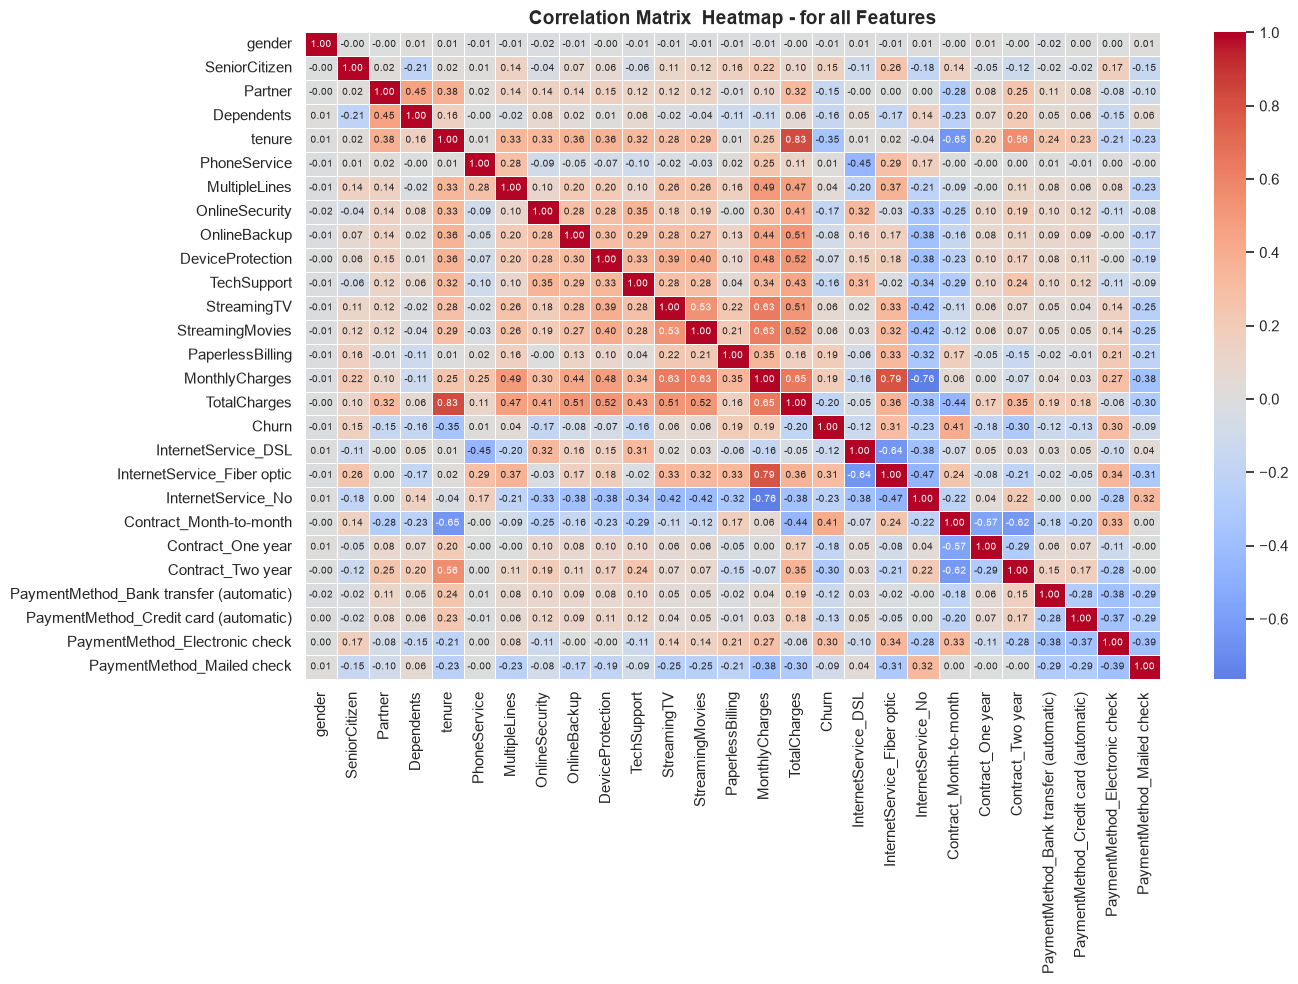


Churn (Ranked) correlation Matrix Heatmap
tenure                                    -0.35
Contract_Two year                         -0.30
InternetService_No                        -0.23
TotalCharges                              -0.20
Contract_One year                         -0.18
OnlineSecurity                            -0.17
TechSupport                               -0.16
Dependents                                -0.16
Partner                                   -0.15
PaymentMethod_Credit card (automatic)     -0.13
InternetService_DSL                       -0.12
PaymentMethod_Bank transfer (automatic)   -0.12
PaymentMethod_Mailed check                -0.09
OnlineBackup                              -0.08
DeviceProtection                          -0.07
gender                                    -0.01
PhoneService                               0.01
MultipleLines                              0.04
StreamingMovies                            0.06
StreamingTV                                0.

In [21]:
# Let Plot a correlation HeatMap on the datasets

plt.figure(figsize=(14,10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5,
    annot_kws={"size":7}
)

plt.title("Correlation Matrix  Heatmap - for all Features",
          fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# The churn analysis in correlation matrix heatmap 
print("=" * 100)
print("\nChurn (Ranked) correlation Matrix Heatmap")
print("=" * 100)
print(correlation_matrix["Churn"].sort_values(ascending=True).round(2))

**Univariate Analysis**

Stayed[1] and Churned[0] Customer: Churn
0    5174
1    1869
Name: count, dtype: int64


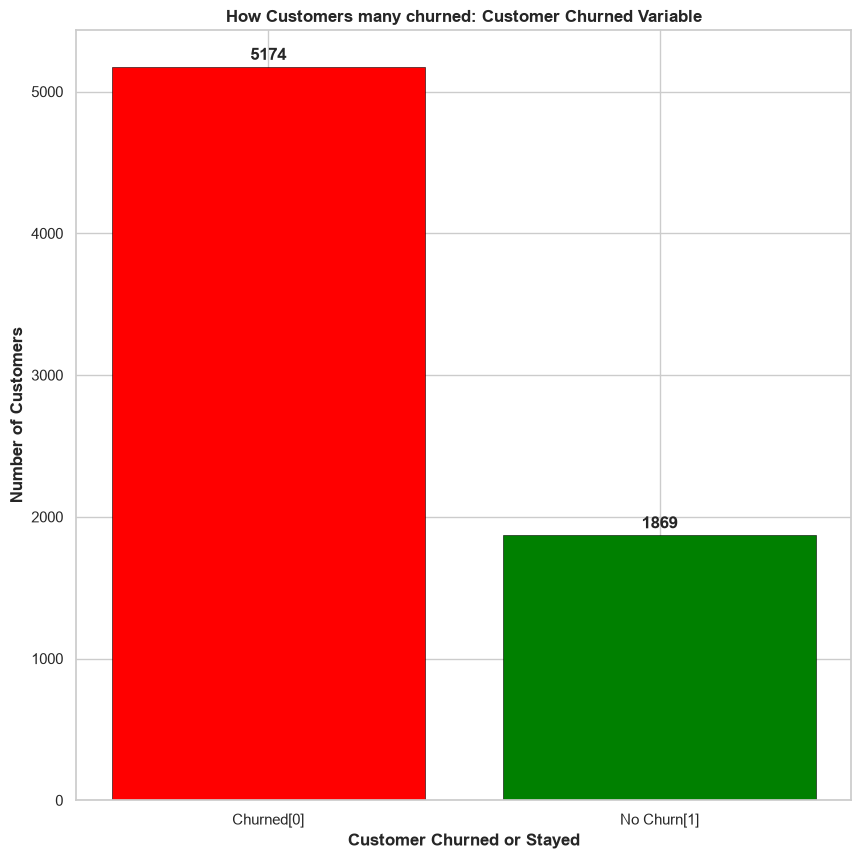

In [22]:
# CHURNED DISTRIBUTION
# creating a visualization on how Customer churned and how many customners stayed

plt.figure(figsize=(10,10))


churn_counts = df["Churn"].value_counts()
colors = ["red","green"]
plt.bar(
    ["Churned[0]", "No Churn[1]"],
    churn_counts.values,
    color = colors,
    edgecolor= "black",
    linewidth=0.4
)
for i, v in enumerate(churn_counts.values):
    plt.text(i, v+50 , str(v),ha="center", fontweight="bold")

plt.title("How Customers many churned: Customer Churned Variable", ha="center", fontweight="bold")
plt.ylabel("Number of Customers", ha="center", fontweight= "bold")
plt.xlabel("Customer Churned or Stayed", ha="center", fontweight="bold")
print(f"Stayed[1] and Churned[0] Customer: {df["Churn"].value_counts()}")


The Distribution Of Customers that are Non-citizen & Citizen


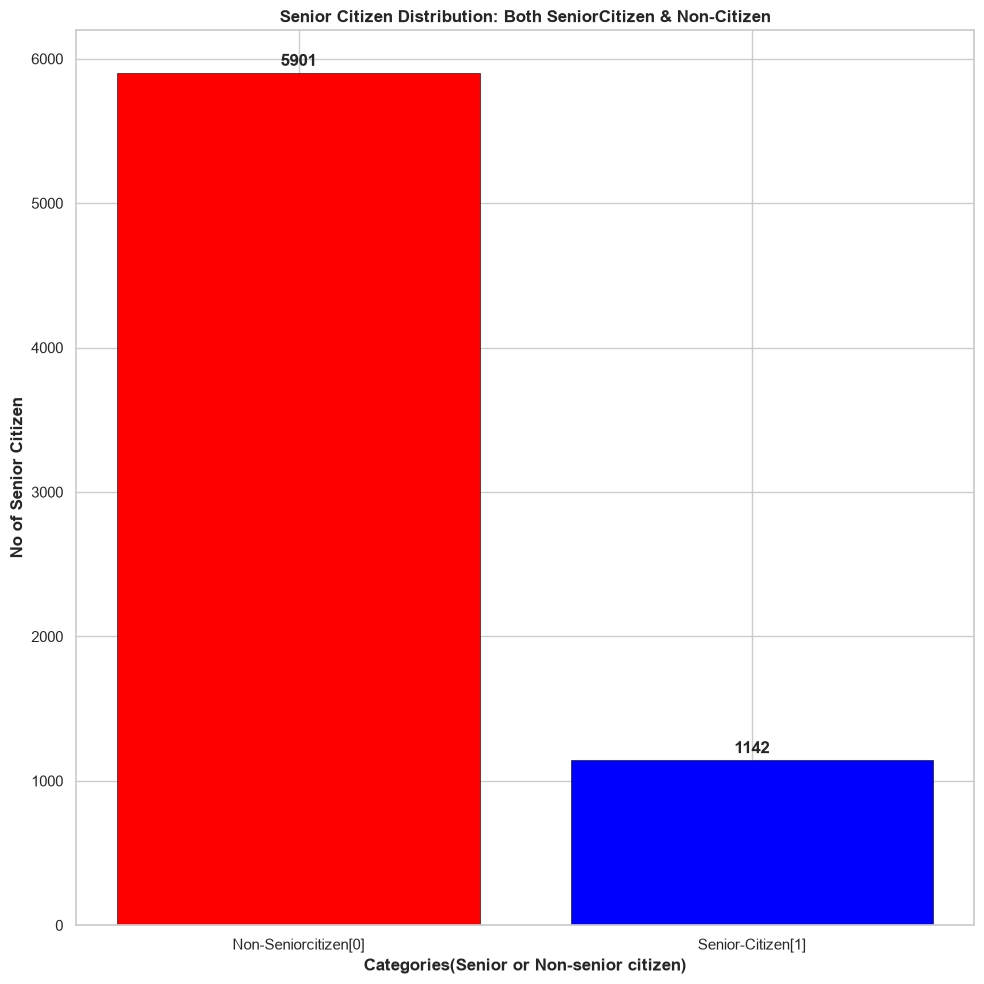

The SeniorCitizen and  Non-seniorcitizen: SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


In [23]:
# Checking the number of Customers that aree senior citizen or not
# SeniorCitizen[1] & Non-Citizen[0]

plt.figure(figsize=(10,10))

citizen_dist = df["SeniorCitizen"].value_counts()

print("=" *100)
print("The Distribution Of Customers that are Non-citizen & Citizen")
print("=" * 100)

plt.bar(
    ["Non-Seniorcitizen[0]", "Senior-Citizen[1]"],
    citizen_dist.values,
    color = ["red", "blue"],
    edgecolor = "black",
    linewidth = 0.4
)

# Puttin the figures ontop of the bar
for i , v in enumerate(citizen_dist):
    plt.text(i, v+50, str(v), ha="center", fontweight="bold")

plt.title("Senior Citizen Distribution: Both SeniorCitizen & Non-Citizen", fontweight="bold")
plt.ylabel("No of Senior Citizen", fontweight="bold", ha="center"),
plt.xlabel("Categories(Senior or Non-senior citizen)", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"The SeniorCitizen and  Non-seniorcitizen: {citizen_dist}")

In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,True,False,False,False,False,True,False


Checking how long customers stayed with Us


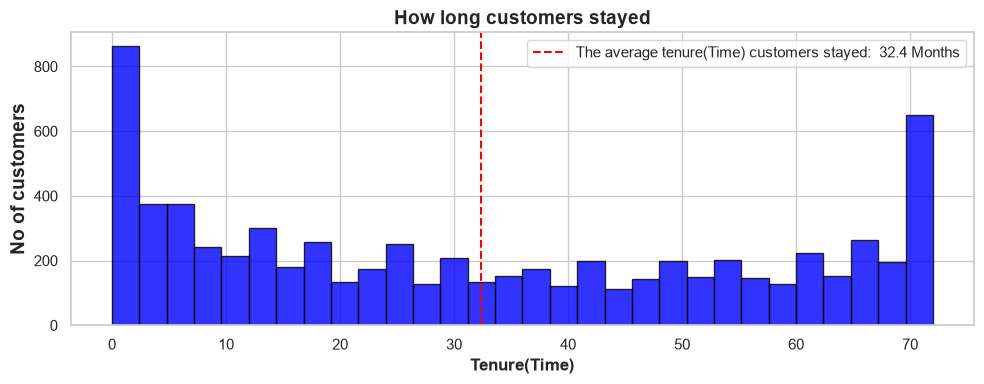

In [ ]:
# Distribution of Tenure
print("=" *100)
print("Checking how long customers stayed with Us")
print("=" *100)

plt.figure(figsize=(10,4
                    ))

plt.hist(
    df["tenure"],
    bins=30,
    color = "blue",
    edgecolor= "black",
    alpha = 0.8
)

plt.axvline(df["tenure"].mean(), color="red", linestyle="--", label= f"The average tenure(Time) customers stayed: {df["tenure"].mean(): .1f} Months")

plt.title("How long customers stayed", ha = "center", fontweight="bold",fontsize=14)
plt.ylabel("No of customers",fontweight="bold", fontsize=14)
plt.xlabel("Tenure(Time)", fontweight="bold",ha="center")
plt.legend()
plt.tight_layout()
plt.show()


 Total Charges paid by the Customer


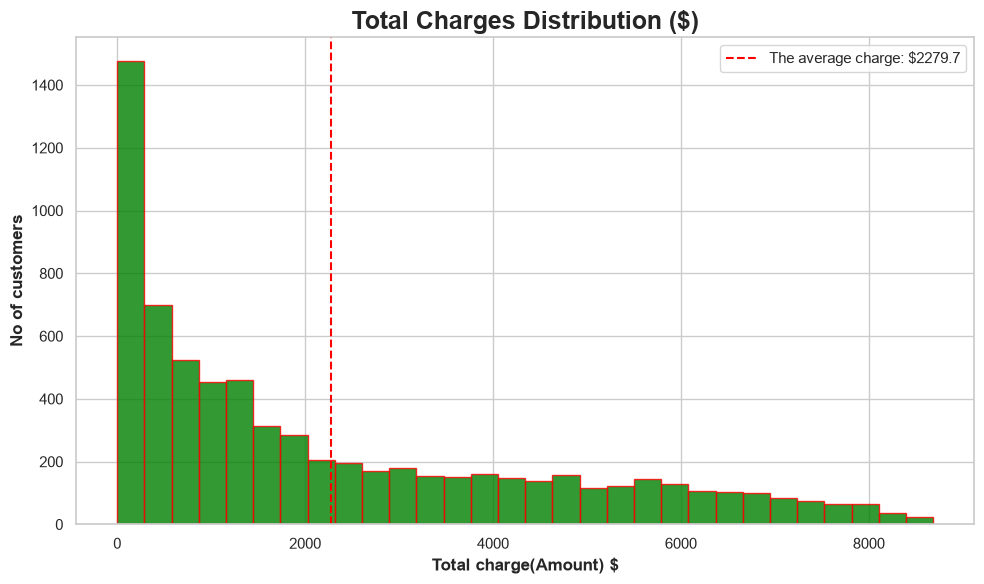

In [26]:
# Checking the amount of customers paid by the customers
print("=" *100)
print("\n Total Charges paid by the Customer")
print("=" *100)
plt.figure(figsize=(10,6))

plt.hist(
    df["TotalCharges"],
    bins=30,
    color="green",
    edgecolor="red",
    alpha=0.8
)

plt.axvline(
    df["TotalCharges"].mean(), color="red", linestyle="--", label= f"The average charge: ${df["TotalCharges"].mean():.1f}"
)
plt.title("Total Charges Distribution ($)", fontweight="bold", fontsize=18)
plt.ylabel("No of customers", fontweight="bold")
plt.xlabel("Total charge(Amount) $", fontweight="bold")
plt.tight_layout()
plt.legend()
plt.show()



## PHASE 4 ->> FEATURES ENGINEERING: DATA SPLITTING & MODEL TRAINING ##

In [27]:
# Spliting Features from Taraget(Churn) 
# using 80% Train and 20% Test

X = df.drop(columns=["Churn","InternetService","Contract","PaymentMethod"],
            errors="ignore") # Features Variables


y = df["Churn"] # Target Features

print(f"\n Features splitted from trained successfully")

print(f"\n X features Shape: {X.shape[0]}")
print(f" Target variables(y) shape: {y.shape[0]}")
print(f"\n New Target variables (X): {X.columns.shape[0]}")

for x in X.columns:
    print(f" ->> {x}")


 Features splitted from trained successfully

 X features Shape: 7043
 Target variables(y) shape: 7043

 New Target variables (X): 26
 ->> gender
 ->> SeniorCitizen
 ->> Partner
 ->> Dependents
 ->> tenure
 ->> PhoneService
 ->> MultipleLines
 ->> OnlineSecurity
 ->> OnlineBackup
 ->> DeviceProtection
 ->> TechSupport
 ->> StreamingTV
 ->> StreamingMovies
 ->> PaperlessBilling
 ->> MonthlyCharges
 ->> TotalCharges
 ->> InternetService_DSL
 ->> InternetService_Fiber optic
 ->> InternetService_No
 ->> Contract_Month-to-month
 ->> Contract_One year
 ->> Contract_Two year
 ->> PaymentMethod_Bank transfer (automatic)
 ->> PaymentMethod_Credit card (automatic)
 ->> PaymentMethod_Electronic check
 ->> PaymentMethod_Mailed check


In [28]:
# Training and testing of Datasets using 80% train and 20% Test

# Using Train_test_split

print("=" *100) 

print(f"\nUsing Train test split for Features(X)80% & Target(y) 20%")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

print(f"Split successful")

print("=" *100)
print("\n The details X and Y includes:")
print("=" * 100)

print(f"\n The shape of the Trained features(X): {X_train.shape[0]} 80% customers")
print(f" The shape of Test features(y): {X_test.shape[0]} 20% customers")
print(f"\n The rate(Churned) of the Trained target variables: {y_train.mean()*100: .1f}%")
print(f" The rate (Churned) of the Test target variables: {y_test.mean()*100: .1f}%")



Using Train test split for Features(X)80% & Target(y) 20%
Split successful

 The details X and Y includes:

 The shape of the Trained features(X): 5634 80% customers
 The shape of Test features(y): 1409 20% customers

 The rate(Churned) of the Trained target variables:  26.5%
 The rate (Churned) of the Test target variables:  26.5%


**DATA NORMALIZATION: Using StandardScaler**

In [29]:
# Using the on Train Data with the highest margin the between the minimum and maximum value
norm_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Using StandardScaler to normalize norm_cols

scaler = StandardScaler()
X_train[norm_cols] = scaler.fit_transform(X_train[norm_cols])
X_test[norm_cols] = scaler.transform(X_test[norm_cols])

print(f"\n Trained data scaled successfully")

print(f"{X_train[norm_cols].describe().round(2)}")



 Trained data scaled successfully
       tenure  MonthlyCharges  TotalCharges
count 5634.00         5634.00       5634.00
mean     0.00           -0.00          0.00
std      1.00            1.00          1.00
min     -1.32           -1.55         -1.01
25%     -0.96           -0.96         -0.83
50%     -0.14            0.19         -0.39
75%      0.95            0.84          0.66
max      1.60            1.81          2.83


In [30]:
# Applied smote to the target variable because of highest difference
# Only on the trained data (X_train $ y_train)

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train,y_train)

print("Smote Applied Successfully")

print(f"\n ======Before Smote====")
print(f" No churn: {sum(y_train ==0)} Customers")
print(f" Churn: {sum(y_train ==1)} Customers")

print(f"\n ======After Smote====")
print(f" No churn: {sum(y_train_sm ==0)} Customers")
print(f" Churn: {sum(y_train_sm ==1)} Customers")


print(f"\nNew target trained: {y_train_sm.shape[0]} Customers")
print(f"\nNew Features trained: {X_train_sm.shape[0]} Customers")


Smote Applied Successfully

 ======Before Smote====
 No churn: 4139 Customers
 Churn: 1495 Customers

 ======After Smote====
 No churn: 4139 Customers
 Churn: 4139 Customers

New target trained: 8278 Customers

New Features trained: 8278 Customers


##  PHASE 5: BUILDING & TRAINING MODEL ##

In [31]:
print("=" *100)
print(f" \n Using the 4 Different Models: \n =>> LogisticsRegression, \n ==> RandomForestClassifier, \n ==> XGBClassifier, \n ==> DecisionTreeClassifier")
print("="*100)

print(f"\n Model 1: LogisticsRegression")
print("Model Building  and Training")

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sm,y_train_sm)

print("=" *100)
print(f"\n Model Prediction")

lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]




print(f"\n Model Prediction Report using classification Report")

print(classification_report(y_test, lr_pred,
                            target_names=["No Churn","Churn"]))

print(f"\n ROC_AUC_SCORE: {roc_auc_score(y_test, lr_proba): .4f}")

lr_model




 
 Using the 4 Different Models: 
 =>> LogisticsRegression, 
 ==> RandomForestClassifier, 
 ==> XGBClassifier, 
 ==> DecisionTreeClassifier

 Model 1: LogisticsRegression
Model Building  and Training

 Model Prediction

 Model Prediction Report using classification Report
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.54      0.73      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409


 ROC_AUC_SCORE:  0.8328


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [32]:
print("=" * 100)
print("Model 2: RandomForestClassifier")
print("\n Building & Traing model")
print("=" *100)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, criterion="entropy")
rf_model.fit(X_train_sm, y_train_sm)

print(f"\n Model Prediiction")
print("=" *100)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]


print(f"\n Classification Report for RandomForest Algorithm")
print("=" * 100)

print(classification_report(y_test, rf_pred,
                            target_names=["No churn","Churn"]))

print(f" ROC_AUC_SCORE(RandomForestAlgorithm): {roc_auc_score(y_test, rf_proba): .4f}")


rf_model


Model 2: RandomForestClassifier

 Building & Traing model

 Model Prediiction

 Classification Report for RandomForest Algorithm
              precision    recall  f1-score   support

    No churn       0.86      0.82      0.84      1035
       Churn       0.55      0.62      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409

 ROC_AUC_SCORE(RandomForestAlgorithm):  0.8262


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap boot

In [33]:
print("=" * 100)
print("Model 2: XGBClassifier")
print("\n Building & Traing model")
print("=" *100)

xgb_model = XGBClassifier(n_estimators=100, 
                          random_state=42,
                            eval_metrics="logloss",
                             verbosity=0 )
xgb_model.fit(X_train_sm, y_train_sm)

print(f"\n Model Prediiction")
print("=" *100)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]


print(f"\n Classification Report for XGBClassifier Algorithm")
print("=" * 100)

print(classification_report(y_test, rf_pred,
                            target_names=["No churn","Churn"]))

print(f" XGBClassifier: {roc_auc_score(y_test, xgb_proba): .4f}")


xgb_model

Model 2: XGBClassifier

 Building & Traing model

 Model Prediiction

 Classification Report for XGBClassifier Algorithm
              precision    recall  f1-score   support

    No churn       0.86      0.82      0.84      1035
       Churn       0.55      0.62      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409

 XGBClassifier:  0.8120


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [34]:
print("=" * 100)
print("Model 2: DecisionTreeClassifier")
print("\n Building & Traing model")
print("=" *100)

dt_model = DecisionTreeClassifier(criterion="entropy",random_state=42,)
dt_model.fit(X_train_sm, y_train_sm)

print(f"\n Model Prediiction")
print("=" *100)

dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]


print(f"\n Classification Report for XGBClassifier Algorithm")
print("=" * 100)

print(classification_report(y_test, dt_pred,
                            target_names=["No churn","Churn"]))

print(f" ROC_AUC_SCORE(DecisionTreeClassifier Algorithm): {roc_auc_score(y_test, dt_proba): .4f}")


dt_model

Model 2: DecisionTreeClassifier

 Building & Traing model

 Model Prediiction

 Classification Report for XGBClassifier Algorithm
              precision    recall  f1-score   support

    No churn       0.83      0.78      0.80      1035
       Churn       0.48      0.55      0.51       374

    accuracy                           0.72      1409
   macro avg       0.65      0.67      0.66      1409
weighted avg       0.73      0.72      0.73      1409

 ROC_AUC_SCORE(DecisionTreeClassifier Algorithm):  0.6693


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

## PHASE 6 : MODEL EVALUATION & VISUALIZATION ##


 Visualizing the Confusion Matrix


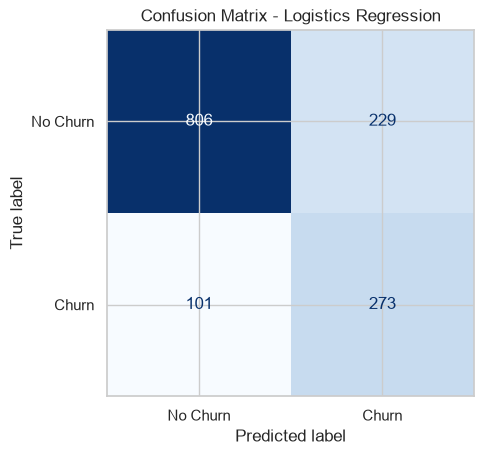

True Negative(Correctly said stayed): 806
False Positive(Wrongly said churned): 101
False Negative(Missed churners): 229
True Positive(Correctly caught): 273


In [35]:
# Using Confusion Matrix for Logistics Regression

print("=" *100)
print(f"\n Visualizing the Confusion Matrix")
print("=" * 100)

cm = confusion_matrix(y_test,lr_pred)

fig, ax = plt.subplots(figsize=(5,7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                        display_labels=["No Churn","Churn"])

disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("Confusion Matrix - Logistics Regression")
plt.tight_layout()
plt.show()


tn, fn, fp, tp = cm.ravel()

print(f"True Negative(Correctly said stayed): {tn}")
print(f"False Positive(Wrongly said churned): {fp}")
print(f"False Negative(Missed churners): {fn}")
print(f"True Positive(Correctly caught): {tp}")

The Confusion matrix of Logistics Regression captures 273 of churner and missed the 101 churners of the total churners. It got 229 wrong as churners


 Visualizing the Confusion Matrix


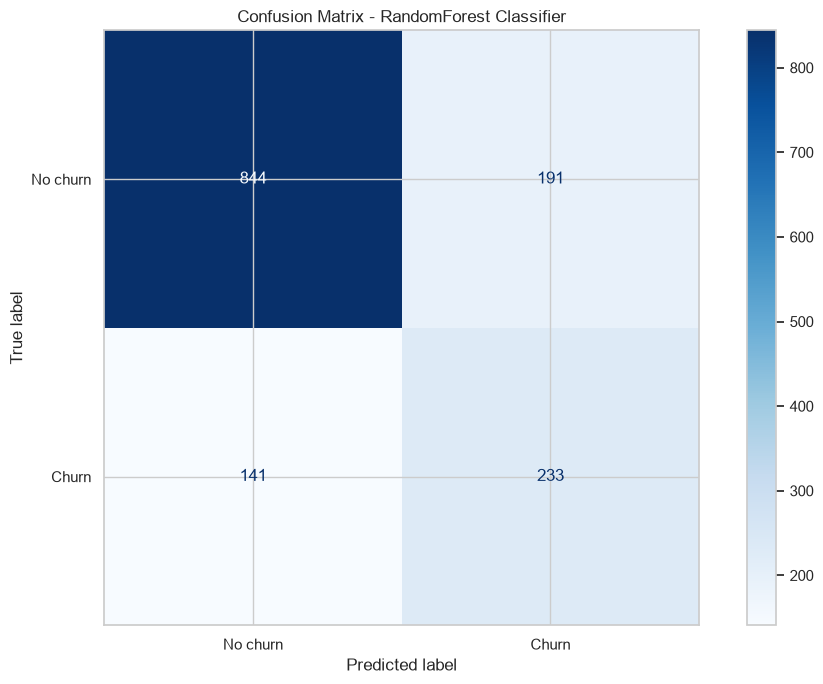

True Negative(correctly said stayed): 844
False Negative(Missed churners): 191
False Positive(Wrongly said churned: 141
True Positive(Actual churn predicted): 233


In [36]:
# Using Confusion Matrix for RandomForest Classifier

print("=" *100)
print(f"\n Visualizing the Confusion Matrix")
print("=" * 100)

cm = confusion_matrix(y_test,rf_pred)

fig, ax = plt.subplots(figsize=(10,7))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No churn","Churn"])

disp.plot(ax=ax, cmap="Blues",colorbar="False")

ax.set_title("Confusion Matrix - RandomForest Classifier")
plt.tight_layout()
plt.show()

tn, fn, fp, tp = cm.ravel()

print(f"True Negative(correctly said stayed): {tn}")
print(f"False Negative(Missed churners): {fn}")
print(f"False Positive(Wrongly said churned: {fp}")
print(f"True Positive(Actual churn predicted): {tp}")

The Confusion matrix of RandomForest captures 233 of churner and missed the 141 churners of the total churners. It got 191 wrong as churners


 Visualizing the Confusion Matrix


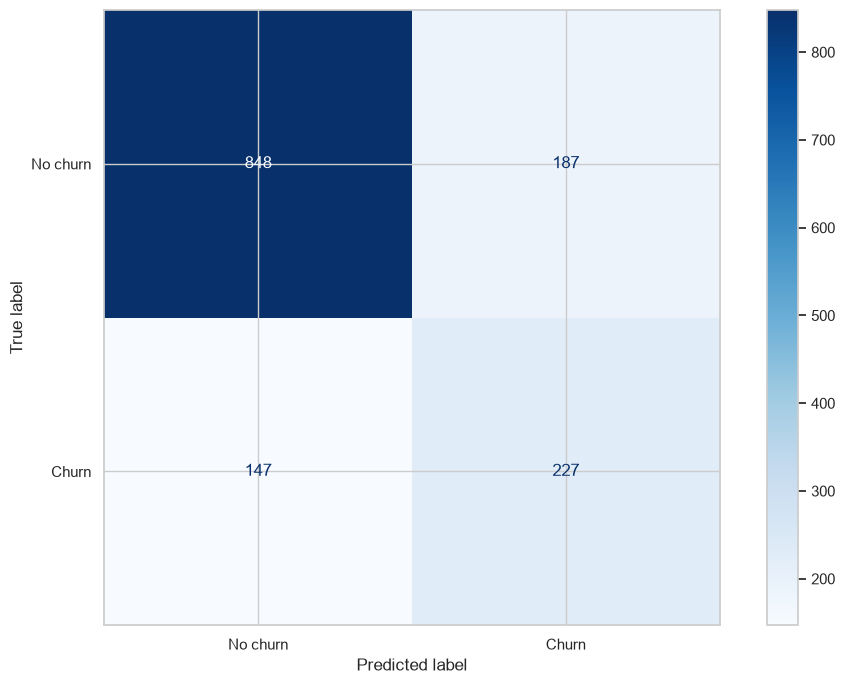

True Negative(correctly said stayed): 848
False Negative(Missed churners): 187
False Positive(Wrongly said churned: 147
True Positive(Actual churn predicted): 227


In [37]:
# Using Confusion Matrix for XGBClassifier

print("=" *100)
print(f"\n Visualizing the Confusion Matrix")
print("=" * 100)

cm = confusion_matrix(y_test, xgb_pred)

fig, ax = plt.subplots(figsize=(10,7))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No churn","Churn"])


disp.plot(ax=ax, cmap="Blues", colorbar="False")

ax.set_title = ("Confusion Matrix - XGBClassifier")
plt.tight_layout()
plt.show()

tn, fn, fp, tp = cm.ravel()

print(f"True Negative(correctly said stayed): {tn}")
print(f"False Negative(Missed churners): {fn}")
print(f"False Positive(Wrongly said churned: {fp}")
print(f"True Positive(Actual churn predicted): {tp}")

The Confusion matrix of XGBClassifier captures 227 of churner and missed the 147 churners of the total churners. It got 187 wrong as churners


 Visualizing the Confusion Matrix


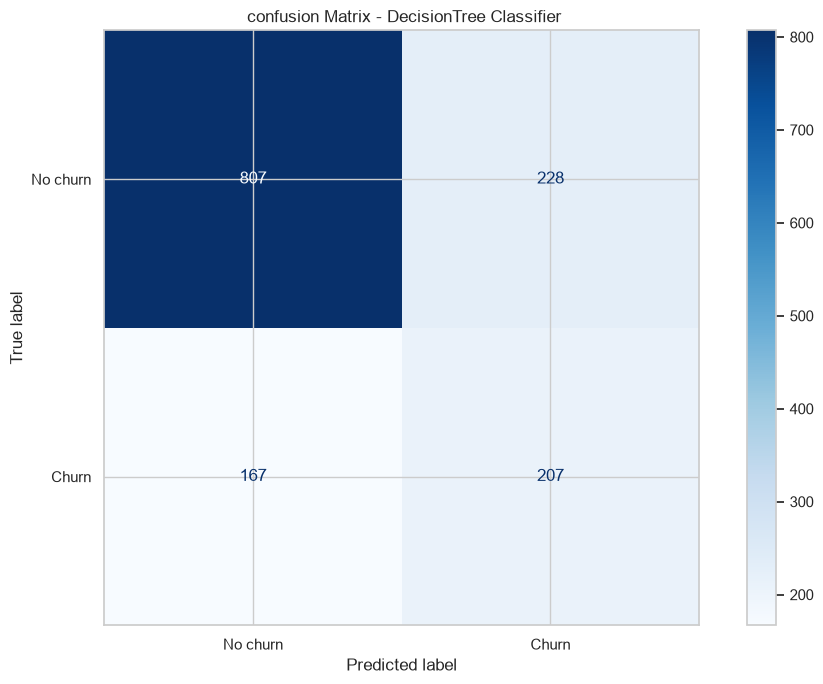

True Negative(correctly said stayed): 807
False Negative(Missed churners): 228
False Positive(Wrongly said churned: 167
True Positive(Actual churn predicted): 207


In [38]:
# Using Confusion Matrix for DecisionTreeClassifier

print("=" *100)
print(f"\n Visualizing the Confusion Matrix")
print("=" * 100)

cm = confusion_matrix(y_test, dt_pred)

fig, ax = plt.subplots(figsize=(10,7))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No churn","Churn"] )

disp.plot(ax=ax, cmap="Blues", colorbar="False")

ax.set_title(" confusion Matrix - DecisionTree Classifier")
plt.tight_layout()
plt.show()

tn, fn, fp, tp = cm.ravel()

print(f"True Negative(correctly said stayed): {tn}")
print(f"False Negative(Missed churners): {fn}")
print(f"False Positive(Wrongly said churned: {fp}")
print(f"True Positive(Actual churn predicted): {tp}")

The Confusion matrix of DecisionTreeClassifier captures 207 of churner and missed the 167 churners of the total churners. It got 228 wrong as churners


 ROC Curve:


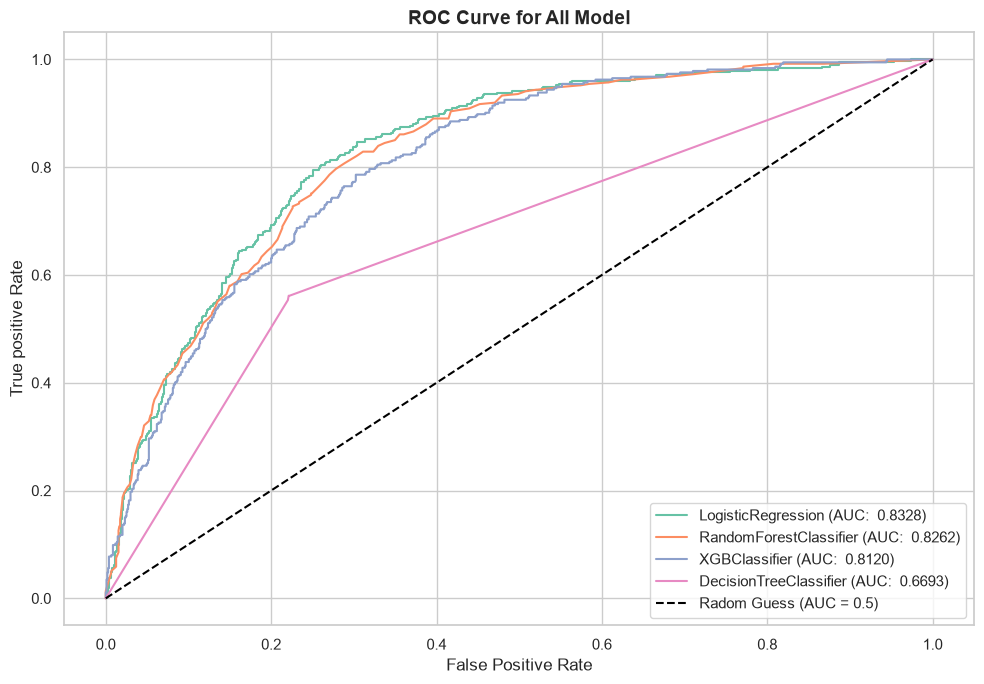

ROC  Score information:
LogisticRegression:  0.8328
RandomForestClassifier:  0.8262
XGBClassifier: 0.8119907515048179
DecisionTreeClassifier: 0.669292670955075


In [39]:
# Plottin the ROC curve for the all the models

print("=" *100)
print(f"\n ROC Curve:")
print("=" * 100)


plt.figure(figsize=(10,7))

probabilities = [
    ("LogisticRegression",lr_proba),
    ("RandomForestClassifier", rf_proba),
    ("XGBClassifier", xgb_proba),
    ("DecisionTreeClassifier", dt_proba)
]

for name, proba in probabilities:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC: {auc: .4f})")


# Radom Guess Baseline

plt.plot([0,1],[0,1], "--k", label = "Radom Guess (AUC = 0.5)")

plt.title("ROC Curve for All Model", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True positive Rate")
plt.tight_layout()
plt.legend()
plt.show()


print("ROC  Score information:")

print(f"LogisticRegression: {roc_auc_score(y_test, lr_proba): .4f}")
print(f"RandomForestClassifier: {roc_auc_score(y_test, rf_proba): .4f}")
print(f"XGBClassifier: {roc_auc_score(y_test, xgb_proba)}")
print(f"DecisionTreeClassifier: {roc_auc_score(y_test, dt_proba)}")






**From the chart Logistics Regression is still best. it predicts the actual churners the more, comapre to other 3 models**

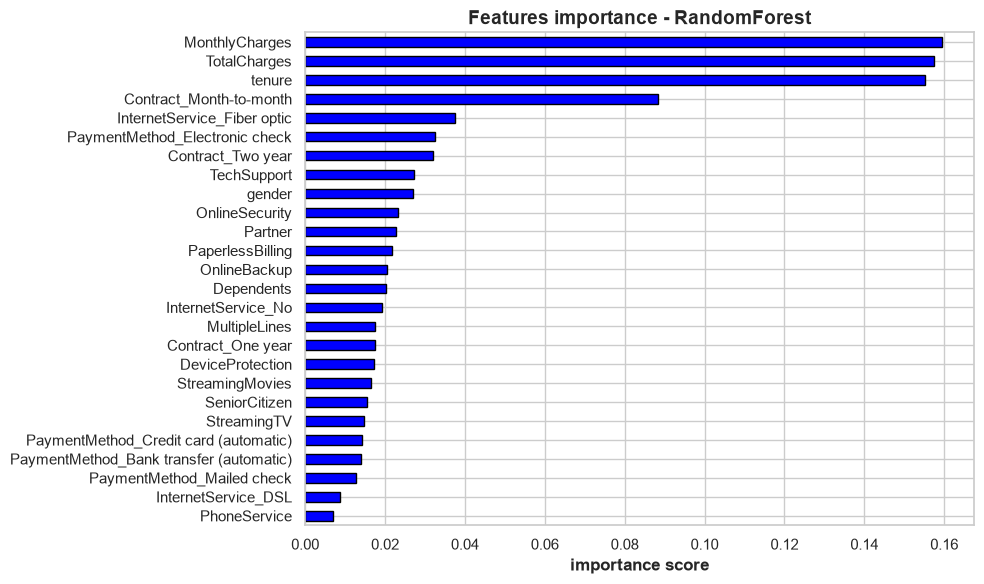

Top 5 Features Importance
MonthlyCharges                0.16
TotalCharges                  0.16
tenure                        0.16
Contract_Month-to-month       0.09
InternetService_Fiber optic   0.04
dtype: float64


In [40]:
# The best Features Importance

importances = pd.Series(rf_model.feature_importances_,
                        index=X.columns)


importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10,6))

importances.plot(kind="barh",
                 color="blue",edgecolor="black")


plt.title("Features importance - RandomForest", fontsize=14, fontweight="bold")
plt.xlabel("importance score", fontweight="bold")
plt.tight_layout()
plt.show()


print("Top 5 Features Importance")
print(importances.sort_values(ascending=False).head())




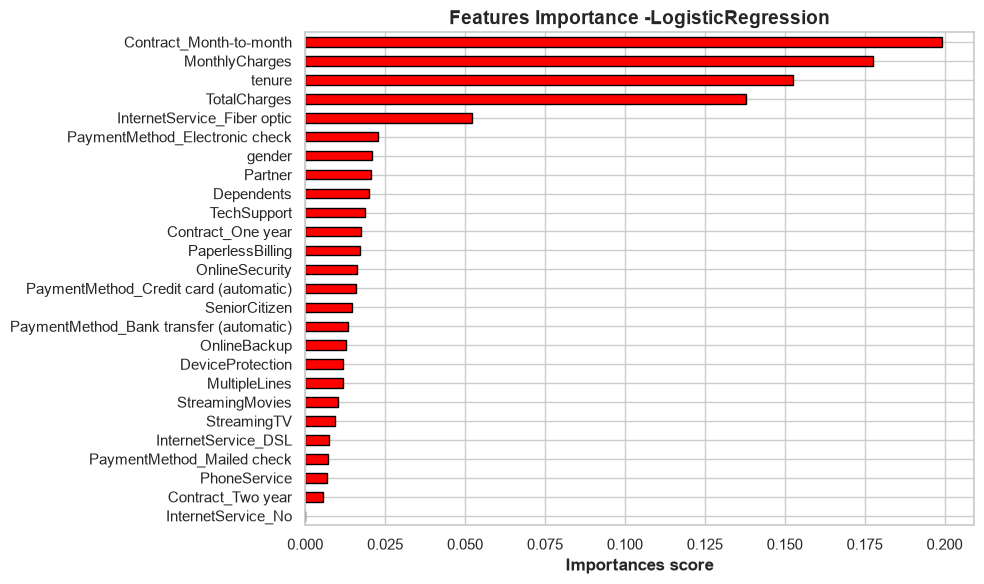

Top 5 importance Features
Contract_Month-to-month       0.20
MonthlyCharges                0.18
tenure                        0.15
TotalCharges                  0.14
InternetService_Fiber optic   0.05
dtype: float64


In [41]:
# Let use Logistics Regression for Features importance

importances = pd.Series(dt_model.feature_importances_,
                        index=X.columns)


importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10,6))

importances.plot(kind="barh",
                 color="red",edgecolor="black")


plt.title("Features Importance -LogisticRegression", fontweight="bold",
          fontsize=14)


plt.xlabel("Importances score", fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 5 importance Features")
print(importances.sort_values(ascending=False).head())


 Model Comparison


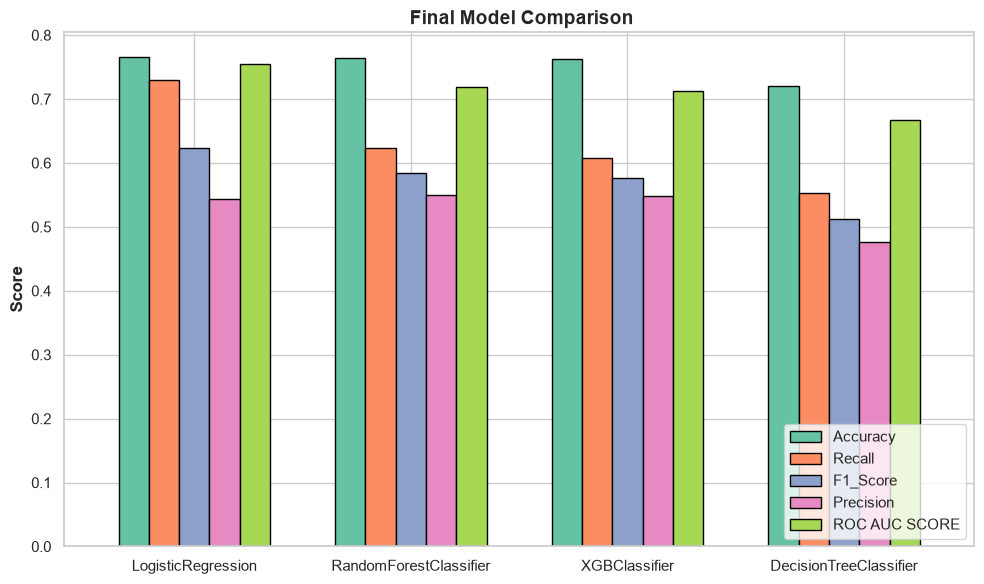

Model result score:
                        Accuracy  Recall  F1_Score  Precision  ROC AUC SCORE
LogisticRegression          0.77    0.73      0.62       0.54           0.75
RandomForestClassifier      0.76    0.62      0.58       0.55           0.72
XGBClassifier               0.76    0.61      0.58       0.55           0.71
DecisionTreeClassifier      0.72    0.55      0.51       0.48           0.67


In [42]:
# MODEL COMPARISON

print("=" *100)
print(f"\n Model Comparison")
print("=" * 100)


Models = [
    "LogisticRegression",
    "RandomForestClassifier",
    "XGBClassifier",
    "DecisionTreeClassifier"
]

metrics = {
    "Accuracy": [
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test,dt_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test,xgb_pred),
        recall_score(y_test,dt_pred)
    ],
    "F1_Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test,dt_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred),
        precision_score(y_test,dt_pred)
    ],
    "ROC AUC SCORE": [
        roc_auc_score(y_test,lr_pred),
        roc_auc_score(y_test, rf_pred),
        roc_auc_score(y_test,xgb_pred),
        roc_auc_score(y_test,dt_pred)
    ]  
}



result_df = pd.DataFrame(metrics,index=Models)

result_df.plot(kind="bar", figsize=(10,6),
               edgecolor="black", width=0.7)


plt.title(" Final Model Comparison", fontweight="bold",ha="center",
          fontsize=14)
plt.ylabel("Score", fontweight="bold")
plt.xticks(rotation=0),
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Model result score:")
print(result_df.round(4))


In [43]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [44]:
# Save the Model
import joblib

joblib.dump(lr_model, "churn_model.pkl")
joblib.dump(scaler,"churn_scaler.pkl")
joblib.dump(X.columns, "Churn_features.pkl")

['Churn_features.pkl']